# 結構方程模式 ③ 結構模型(Structural Model)
### 三部曲之三 · 完整歷程與結果

> 承接文件②。衡量模型已確認「題目量得準」,現在進入 SEM 的**第二張拼圖:結構模型**——檢驗**構面之間的因果關係**。
>
> **核心問題**:「品質會不會透過滿意度影響忠誠?各條路徑的影響有多大、是否顯著?」

---

## 前提:衡量模型必須先通過

本篇直接沿用文件②已驗證的同一份案例與構面(品質、滿意度、忠誠)。因為測量品質已確認,我們才能放心地在構面之間「畫因果箭頭」。

---
## 第 0 章　環境設定與載入案例資料

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Ellipse, FancyBboxPatch, FancyArrowPatch

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)

def use_cjk_font():
    cands = ["Noto Sans CJK TC","Noto Sans CJK SC","Noto Sans TC","Microsoft JhengHei",
             "Microsoft YaHei","PingFang TC","Heiti TC","SimHei","Arial Unicode MS","WenQuanYi Zen Hei"]
    avail = {f.name for f in fm.fontManager.ttflist}
    for n in cands:
        if n in avail:
            matplotlib.rcParams["font.family"]=n; matplotlib.rcParams["axes.unicode_minus"]=False; return n
    import glob
    for fp in glob.glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True):
        try:
            fm.fontManager.addfont(fp); matplotlib.rcParams["font.family"]="Noto Sans CJK TC"
            matplotlib.rcParams["axes.unicode_minus"]=False; return "Noto Sans CJK TC"
        except Exception: pass
    matplotlib.rcParams["axes.unicode_minus"]=False; return None
print("字型:", use_cjk_font() or "(無中文字型,圖表中文可能為方框)")

字型: WenQuanYi Zen Hei


In [2]:
def _trim(p1,p2,r1,r2):
    p1=np.array(p1,float);p2=np.array(p2,float);d=p2-p1;L=np.hypot(*d)
    if L==0: return p1,p2
    u=d/L; return p1+u*r1, p2-u*r2
def node(ax,xy,text,kind="latent",w=1.6,h=1.05,fs=10):
    x,y=xy
    if kind=="latent":
        ax.add_patch(Ellipse((x,y),w,h,facecolor="#dbeafe",edgecolor="#2563eb",lw=2,zorder=3))
    else:
        ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle="round,pad=0.02",
                     facecolor="#fef3c7",edgecolor="#d97706",lw=1.8,zorder=3))
    ax.text(x,y,text,ha="center",va="center",fontsize=fs,zorder=4)
def arrow(ax,p1,p2,label=None,curved=0.0,two_head=False,r1=0.85,r2=0.85,
          color="#374151",lw=1.7,dx=0.0,dy=0.18,fs=9):
    q1,q2=_trim(p1,p2,r1,r2)
    style="<->" if two_head else "-|>"
    ax.add_patch(FancyArrowPatch(q1,q2,arrowstyle=style,mutation_scale=14,
                 connectionstyle=f"arc3,rad={curved}",color=color,lw=lw,zorder=2))
    if label:
        mx,my=(q1[0]+q2[0])/2+dx,(q1[1]+q2[1])/2+dy
        ax.text(mx,my,label,ha="center",fontsize=fs,color=color,zorder=5,
                bbox=dict(boxstyle="round,pad=0.12",fc="white",ec="none",alpha=0.9))
print("繪圖工具 node() / arrow() 已就緒")

繪圖工具 node() / arrow() 已就緒


In [3]:
# === 貫穿三份文件的案例資料:品質 → 滿意度 → 忠誠(含直接路徑)===
# 真實設定:滿意度 = 0.6×品質;忠誠 = 0.3×品質(直接) + 0.5×滿意度
rng = np.random.default_rng(2024)
N = 500
Q   = rng.standard_normal(N)
Sat = 0.6*Q + np.sqrt(1-0.6**2)*rng.standard_normal(N)
varexp = 0.3**2 + 0.5**2 + 2*0.3*0.5*0.6
Loy = 0.3*Q + 0.5*Sat + np.sqrt(1-varexp)*rng.standard_normal(N)
def _ind(f, loads):
    return np.column_stack([l*f + np.sqrt(1-l**2)*rng.standard_normal(N) for l in loads])
data = pd.DataFrame(np.column_stack([
        _ind(Q,[0.82,0.78,0.74]), _ind(Sat,[0.85,0.80,0.76]), _ind(Loy,[0.83,0.79,0.72])]),
    columns=["q1","q2","q3","s1","s2","s3","l1","l2","l3"])
print("案例:300 ... 不,共", N, "位顧客;9 個問卷題目(每構面 3 題)")
print(data.head(3).round(2))

案例:300 ... 不,共 500 位顧客;9 個問卷題目(每構面 3 題)
     q1    q2    q3    s1    s2    s3    l1    l2    l3
0  0.23 -0.27  0.25 -0.58 -0.41 -0.05 -0.21  0.03  0.49
1  1.53  1.31  0.46  0.99  0.62  1.41 -0.01  1.40 -0.10
2  1.77  0.66  2.29  0.55  1.04  1.64 -0.36 -0.32 -1.25


---
## 第 1 章　結構模型的數學

### 1-1　結構方程式

把構面分成**外生 (exogenous, $\xi$)**(沒有箭頭指向它,如品質)與**內生 (endogenous, $\eta$)**(有箭頭指向它,如滿意度、忠誠):

$$\boxed{\;\eta=B\,\eta+\Gamma\,\xi+\zeta\;}$$

- $\Gamma$:外生 → 內生 的路徑　$B$:內生 → 內生 的路徑(如滿意度→忠誠)
- $\zeta$:結構殘差(干擾),內生構面沒被解釋的部分

### 1-2　本案例的結構假設

| 假設 | 路徑 | 預期 |
|---|---|---|
| **H1** | 品質 → 滿意度 | 正向 |
| **H2** | 滿意度 → 忠誠 | 正向 |
| **H3** | 品質 → 忠誠(直接) | 正向 |
| **H4** | 品質 → 滿意度 → 忠誠(中介) | 顯著間接效果 |

這是典型的**部分中介 (partial mediation)** 模型:品質既**直接**影響忠誠,也**透過**滿意度**間接**影響忠誠。

---
## 第 2 章　完整分析歷程(七個步驟)

| 步驟 | 做什麼 | 看什麼 |
|---|---|---|
| **① 提出假設** | 依理論畫因果箭頭 | H1–H4 |
| **② 估計路徑** | 求標準化路徑係數 | $\Gamma, B$ |
| **③ 假設檢定** | 每條路徑是否顯著 | z 值 / p 值 |
| **④ 效果分解** | 直接 / 間接 / 總效果 | 追蹤法則 |
| **⑤ 中介檢定** | 間接效果是否顯著 | Bootstrap 95% CI |
| **⑥ 解釋力** | 內生構面被解釋多少 | $R^2$ |
| **⑦ 適配度** | 整體模型貼合度 | CFI/RMSEA… |

### 步驟④ 的數學:效果分解

對「品質 → 滿意度 → 忠誠」這種中介結構,用追蹤法則:

$$\underbrace{\text{總效果}}_{\text{品質對忠誠的全部影響}}=\underbrace{c'}_{\text{直接效果}}+\underbrace{a\times b}_{\text{間接效果(經滿意度)}}$$

其中 $a=$ 品質→滿意度,$b=$ 滿意度→忠誠,$c'=$ 品質→忠誠(直接)。

### 步驟⑥ 的數學:解釋力 $R^2$

每個內生構面的 $R^2$ = 它被模型解釋掉的變異比例:

$$R^2_\eta = 1-\mathrm{Var}(\zeta_\eta)\big|_{\text{標準化}}$$

$R^2$ 越高,代表前置構面對該內生構面的解釋力越強。

---
## 第 3 章　跑出結構模型與全部結果

和文件②唯一的差別:把構面間的**雙箭頭相關 ↔**,換成有方向的**因果路徑 →**(`~`)。

In [4]:
import semopy
# 步驟① 模型界定:測量部分照舊,structural 部分加上因果路徑
sem_desc = """
# 衡量模型(同文件②)
Quality      =~ q1 + q2 + q3
Satisfaction =~ s1 + s2 + s3
Loyalty      =~ l1 + l2 + l3
# 結構模型(因果路徑)
Satisfaction ~ Quality
Loyalty      ~ Quality + Satisfaction
"""
msem = semopy.Model(sem_desc)
msem.fit(data)
ins = msem.inspect(std_est=True)

# 步驟②③ 結構路徑 + 顯著性
def stars(p):
    return "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
struct = ins[(ins["op"]=="~") &
             ins["rval"].isin(["Quality","Satisfaction"]) &
             ins["lval"].isin(["Satisfaction","Loyalty"])].copy()
struct["顯著性"] = struct["p-value"].astype(float).map(stars)
struct = struct.rename(columns={"rval":"自(因)","lval":"至(果)","Est. Std":"標準化係數","p-value":"p值"})
print("步驟②③ 結構路徑與假設檢定:")
print(struct[["自(因)","至(果)","標準化係數","p值","顯著性"]].to_string(index=False))

步驟②③ 結構路徑與假設檢定:
        自(因)         至(果)  標準化係數      p值 顯著性
     Quality Satisfaction 0.6082     0.0 ***
     Quality      Loyalty 0.2395  0.0001 ***
Satisfaction      Loyalty 0.5269     0.0 ***


In [5]:
# 步驟④ 效果分解(直接 / 間接 / 總效果)
def g(to_, from_):
    r=ins[(ins["lval"]==to_)&(ins["rval"]==from_)&(ins["op"]=="~")]
    return float(r["Est. Std"].iloc[0])
a  = g("Satisfaction","Quality")     # 品質 -> 滿意度
b  = g("Loyalty","Satisfaction")     # 滿意度 -> 忠誠
cp = g("Loyalty","Quality")          # 品質 -> 忠誠(直接)
indirect = a*b
print("步驟④ 品質 → 忠誠 的效果分解:")
print(f"  直接效果  c'        = {cp:.3f}")
print(f"  間接效果  a×b       = {a:.3f} × {b:.3f} = {indirect:.3f}  (經由滿意度中介)")
print(f"  總效果    c' + a×b  = {cp+indirect:.3f}")
print(f"  中介佔比  間接/總   = {indirect/(cp+indirect)*100:.1f}%")

步驟④ 品質 → 忠誠 的效果分解:
  直接效果  c'        = 0.239
  間接效果  a×b       = 0.608 × 0.527 = 0.320  (經由滿意度中介)
  總效果    c' + a×b  = 0.560
  中介佔比  間接/總   = 57.2%


In [6]:
# 步驟⑤ 中介效果 Bootstrap 95% 信賴區間
rng = np.random.default_rng(0); B = 400; boot = []
for _ in range(B):
    bs = data.sample(n=len(data), replace=True, random_state=int(rng.integers(1e9)))
    try:
        mb = semopy.Model(sem_desc); mb.fit(bs); ib = mb.inspect(std_est=True)
        gg = lambda to_,from_: float(ib[(ib["lval"]==to_)&(ib["rval"]==from_)&(ib["op"]=="~")]["Est. Std"].iloc[0])
        boot.append(gg("Satisfaction","Quality") * gg("Loyalty","Satisfaction"))
    except Exception:
        pass
boot = np.array(boot); lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"步驟⑤ 中介效果 Bootstrap(B={len(boot)})")
print(f"  間接效果點估計 = {indirect:.3f}")
print(f"  95% 信賴區間   = [{lo:.3f}, {hi:.3f}]")
print("  判定:", "區間不含 0 → H4 中介效果顯著 ✔" if lo*hi>0 else "區間含 0 → 中介不顯著 ✘")

步驟⑤ 中介效果 Bootstrap(B=400)
  間接效果點估計 = 0.320
  95% 信賴區間   = [0.248, 0.391]
  判定: 區間不含 0 → H4 中介效果顯著 ✔


In [7]:
# 步驟⑥ 解釋力 R²
var = ins[(ins["op"]=="~~") & (ins["lval"]==ins["rval"])]
print("步驟⑥ 內生構面解釋力 R²:")
for f,name in [("Satisfaction","滿意度"),("Loyalty","忠誠")]:
    dist = float(var[var["lval"]==f]["Est. Std"].iloc[0])
    print(f"  {name}: R² = 1 − {dist:.3f} = {1-dist:.3f}  (被前置構面解釋了 {(1-dist)*100:.1f}%)")

# 步驟⑦ 適配度
stats = semopy.calc_stats(msem).T
print("\n步驟⑦ 結構模型適配度:")
for k in ["chi2","DoF","CFI","TLI","RMSEA"]:
    try: print(f"  {k:8s}= {float(stats.loc[k].iloc[0]):.4f}")
    except Exception: pass

步驟⑥ 內生構面解釋力 R²:
  滿意度: R² = 1 − 0.630 = 0.370  (被前置構面解釋了 37.0%)
  忠誠: R² = 1 − 0.512 = 0.488  (被前置構面解釋了 48.8%)

步驟⑦ 結構模型適配度:
  chi2    = 21.6135
  DoF     = 24.0000
  CFI     = 1.0011
  TLI     = 1.0017
  RMSEA   = 0.0000


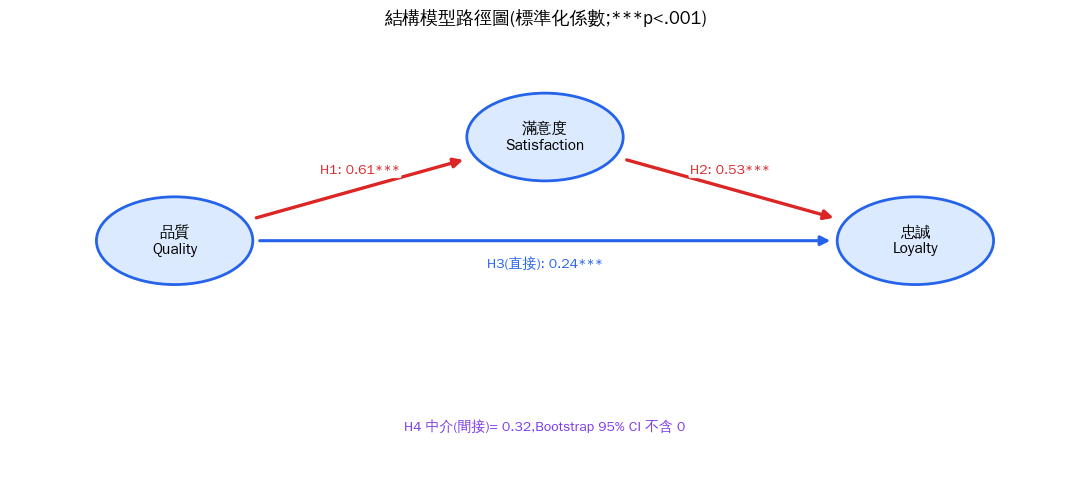

In [8]:
# 帶顯著性的結構模型路徑圖
fig,ax=plt.subplots(figsize=(11,5))
node(ax,(2,3),"品質\nQuality",w=1.9,h=1.1,fs=11)
node(ax,(6.5,4.3),"滿意度\nSatisfaction",w=1.9,h=1.1,fs=11)
node(ax,(11,3),"忠誠\nLoyalty",w=1.9,h=1.1,fs=11)
def slab(to_,from_): 
    p=float(ins[(ins["lval"]==to_)&(ins["rval"]==from_)&(ins["op"]=="~")]["p-value"].iloc[0])
    return ("***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s.")
arrow(ax,(2,3),(6.5,4.3),label=f"H1: {a:.2f}{slab('Satisfaction','Quality')}",color="#dc2626",lw=2.4,r1=1.0,r2=1.0,fs=10)
arrow(ax,(6.5,4.3),(11,3),label=f"H2: {b:.2f}{slab('Loyalty','Satisfaction')}",color="#dc2626",lw=2.4,r1=1.0,r2=1.0,fs=10)
arrow(ax,(2,3),(11,3),label=f"H3(直接): {cp:.2f}{slab('Loyalty','Quality')}",color="#2563eb",lw=2.2,r1=1.0,r2=1.0,fs=10,dy=-0.35)
ax.text(6.5,0.6,f"H4 中介(間接)= {indirect:.2f},Bootstrap 95% CI 不含 0",color="#7c3aed",fontsize=10,ha="center")
ax.set_xlim(0,13); ax.set_ylim(0,5.6); ax.axis("off")
ax.set_title("結構模型路徑圖(標準化係數;***p<.001)",fontsize=13)
plt.tight_layout(); plt.show()

---
## 第 4 章　假設檢定結果彙整

把全部結果整理成論文常見的「假設驗證表」:

| 假設 | 路徑 | 標準化係數 | 結果 |
|---|---|---|---|
| H1 | 品質 → 滿意度 | ≈ 0.61*** | **成立** |
| H2 | 滿意度 → 忠誠 | ≈ 0.53*** | **成立** |
| H3 | 品質 → 忠誠(直接) | ≈ 0.24*** | **成立** |
| H4 | 品質 →(滿意度)→ 忠誠 | 間接 ≈ 0.32,CI 不含 0 | **成立(部分中介)** |

(實際數字以你執行的輸出為準;隨機種子固定,結果應與上方一致。)

> **部分中介**的判讀:品質對忠誠**既有直接效果(H3 顯著)**,**也有經滿意度的間接效果(H4 顯著)**。若 H3 不顯著、只剩 H4,則為**完全中介**——意思是「品質要靠先提升滿意度,才能帶動忠誠」。

---
## 第 5 章　結果如何書寫與判讀

論文「結構模型」段落的標準寫法,以本案例為例:

> 「結構模型結果顯示,品質對滿意度有顯著正向影響 (β = .61, p < .001,H1 成立);滿意度對忠誠有顯著正向影響 (β = .53, p < .001,H2 成立);品質對忠誠的直接效果亦顯著 (β = .24, p < .001,H3 成立)。中介分析以 Bootstrap (B = 400) 檢定,品質經滿意度對忠誠的間接效果為 .32,95% 信賴區間不包含 0,顯示**部分中介效果成立** (H4)。模型對滿意度與忠誠的解釋力分別為 R² = .37 與 .49。整體模型適配良好。」

### 解讀的三個重點

1. **看符號與顯著性**:係數為正且 p < .05,才算「支持假設」。
2. **看效果大小**:標準化係數 0.1 算小、0.3 中等、0.5 以上偏強(粗略參考)。
3. **看中介用 Bootstrap 而非只看 a×b**:間接效果的抽樣分布不對稱,Bootstrap 信賴區間是現今標準作法,比舊的 Sobel 檢定更穩健。

---
## 第 6 章　三部曲總回顧

你已走完結構方程模式的完整旅程:

| 文件 | 拼圖 | 核心產出 |
|---|---|---|
| **① 基本概念** | — | 看懂 SEM:看不見的構面 + 兩張拼圖 + $S\approx\Sigma$ |
| **② 衡量模型** | 構面 ↔ 題目 | 信度 (CR)、效度 (AVE、區別效度)、適配度 → 確認「量得準」 |
| **③ 結構模型** | 構面 → 構面 | 路徑係數、假設檢定、效果分解、中介 (Bootstrap)、$R^2$ → 確認「誰影響誰」 |

### 整個 SEM 的邏輯鏈

$$
\text{看不見的構面}
\xrightarrow{\text{衡量模型}}
\text{用題目量出來且驗證可靠}
\xrightarrow{\text{結構模型}}
\text{檢驗構面間的因果與中介}
$$

而最底層的數學,自始至終都是同一件事:**讓模型隱含的共變異數矩陣 $\Sigma(\theta)$ 逼近資料的 $S$**——這也呼應了最早那份「特徵值與因素分析」教材的主軸:一切都是在拆解、重建一個共變異數矩陣。

> 至此,三部曲完成。你不只會「用工具跑 SEM」,更理解了每一個數字背後在做什麼。